 # Phoneme Mapping Analysis: Heard vs Intended



 This notebook analyses mappings from **intended** (canonical) phonemes to

 **heard/produced** phonemes in the L2-ARCTIC scripted split.



 Goals:

 1. Isolate phoneme mappings by aligning canonical IPA to produced IPA.

 2. Filter out already-correct mappings (e.g. a -> a).

 3. Analyse substitutions globally and by accent/L1.

 4. Produce both numeric outputs (tables/CSVs) and visual outputs (heatmaps/barplots).

 ## Setup

In [2]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd


import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

FONT_PATH = "/usr/share/fonts/truetype/noto/NotoSans-Regular.ttf"

fm.fontManager.addfont(FONT_PATH)
ipa_font = fm.FontProperties(fname=FONT_PATH)
font_name = ipa_font.get_name()
print("Using font:", font_name)

mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

sns.set_theme(style="whitegrid", rc={
    "font.family": font_name,
    "axes.unicode_minus": False,
})

from src.utilsl2arctic import load_scripted

OUTDIR = Path("data/l2_arctic_eda_outputs")
OUTDIR.mkdir(exist_ok=True)


Using font: Noto Sans


 ## Load data



 Update these column names if your loader uses different names.

In [3]:
CANON_COL = "g2p"              # intended phoneme sequence
PROD_COL = "ipa"                         # heard/produced phoneme sequence
L1_COL = "speaker_native_language"       # accent / native language
SPEAKER_COL = "speaker_code"             # optional, used in some analyses

scripted_df = load_scripted()

print("Columns:")
print(scripted_df.columns.tolist())

scripted_df[[CANON_COL, PROD_COL, L1_COL]].head()


Columns:
['ipa', 'text', 'g2p', 'speaker_code', 'speaker_gender', 'speaker_native_language', 'duration_s', 'ipa_wstress', 'text_num_chars', 'text_num_words', 'ipa_num_chars']


,g2p,ipa,speaker_native_language
0,fɔɹðʌtwɛntiʌθtaɪmðætivnɪŋðʌtumɛnʃʊkhændz,fɔɹðʌtwɛntiɪθtaɪmðætivnɪŋkðʌtumɛnʃʊkhænss,Arabic
1,wɪlwiɛvɝfɝɡɛtɪt,wɪlwiɛvʌfɔɹɡɛtɛt,Arabic
2,ɡɑdblɛsɛmaɪhoʊpaɪlɡoʊɑnsiɪŋðɛmfɝɛvɝ,ɡɑdblɛsðʌmaɪhoʊpaɪlɡoʊɔnsiɪŋðɛmfɝɛvʌ,Arabic
3,ʌndjuɔlweɪzwɑnttusiɪtɪnðʌsʊpɝlʌtɪvdɪɡɹi,ændjuɔlwizwɔnttusiɛtɛnðʌsʊbɝlʌtɪvdɪɡɹi,Arabic
4,ɡædjɔɹlɛtɝkeɪmdʒʌstɪntaɪm,ɡædjʊɹlɛtɹkeɪmdʒʌstɪntaɪm,Arabic


 ## Basic sanity checks

In [4]:
print("Rows:", len(scripted_df))
print("Null canonical rows:", scripted_df[CANON_COL].isna().sum())
print("Null produced rows:", scripted_df[PROD_COL].isna().sum())
print("L1 values:", scripted_df[L1_COL].dropna().unique())

Rows: 3599
Null canonical rows: 0
Null produced rows: 0
L1 values: <ArrowStringArray>
['Arabic', 'Chinese', 'Hindi', 'Korean', 'Spanish', 'Vietnamese']
Length: 6, dtype: str


In [5]:
# Keep only rows where both canonical and produced IPA are available
df = scripted_df.dropna(subset=[CANON_COL, PROD_COL, L1_COL]).copy()

print("Usable rows:", len(df))
df[[CANON_COL, PROD_COL, L1_COL]].head()


Usable rows: 3599


,g2p,ipa,speaker_native_language
0,fɔɹðʌtwɛntiʌθtaɪmðætivnɪŋðʌtumɛnʃʊkhændz,fɔɹðʌtwɛntiɪθtaɪmðætivnɪŋkðʌtumɛnʃʊkhænss,Arabic
1,wɪlwiɛvɝfɝɡɛtɪt,wɪlwiɛvʌfɔɹɡɛtɛt,Arabic
2,ɡɑdblɛsɛmaɪhoʊpaɪlɡoʊɑnsiɪŋðɛmfɝɛvɝ,ɡɑdblɛsðʌmaɪhoʊpaɪlɡoʊɔnsiɪŋðɛmfɝɛvʌ,Arabic
3,ʌndjuɔlweɪzwɑnttusiɪtɪnðʌsʊpɝlʌtɪvdɪɡɹi,ændjuɔlwizwɔnttusiɛtɛnðʌsʊbɝlʌtɪvdɪɡɹi,Arabic
4,ɡædjɔɹlɛtɝkeɪmdʒʌstɪntaɪm,ɡædjʊɹlɛtɹkeɪmdʒʌstɪntaɪm,Arabic


 ## Tokenisation



 For now, we treat each IPA character as a phoneme token.

 If you later want to handle multi-character phones (e.g. t͡ʃ), you can replace this tokenizer.

In [6]:
def ipa_to_chars(s: str):
    if not isinstance(s, str):
        return []
    return list(s)


In [7]:
# Example
example_idx = 0
print("Canonical:", df.iloc[example_idx][CANON_COL])
print("Produced: ", df.iloc[example_idx][PROD_COL])
print("Canonical tokens:", ipa_to_chars(df.iloc[example_idx][CANON_COL])[:20])
print("Produced tokens: ", ipa_to_chars(df.iloc[example_idx][PROD_COL])[:20])


Canonical: fɔɹðʌtwɛntiʌθtaɪmðætivnɪŋðʌtumɛnʃʊkhændz
Produced:  fɔɹðʌtwɛntiɪθtaɪmðætivnɪŋkðʌtumɛnʃʊkhænss
Canonical tokens: ['f', 'ɔ', 'ɹ', 'ð', 'ʌ', 't', 'w', 'ɛ', 'n', 't', 'i', 'ʌ', 'θ', 't', 'a', 'ɪ', 'm', 'ð', 'æ', 't']
Produced tokens:  ['f', 'ɔ', 'ɹ', 'ð', 'ʌ', 't', 'w', 'ɛ', 'n', 't', 'i', 'ɪ', 'θ', 't', 'a', 'ɪ', 'm', 'ð', 'æ', 't']


 ## Alignment helper



 We use a simple global alignment (Levenshtein-style dynamic programming).

 We keep aligned pairs where both sides are non-gaps.

 Insertions/deletions are tracked separately.

In [8]:
def align_sequences(src, tgt):
    """
    Global alignment between two token lists.
    Returns aligned src and tgt lists, where gaps are represented by None.
    """
    src = list(src)
    tgt = list(tgt)
    n, m = len(src), len(tgt)

    dp = [[0] * (m + 1) for _ in range(n + 1)]
    back = [[None] * (m + 1) for _ in range(n + 1)]

    for i in range(1, n + 1):
        dp[i][0] = i
        back[i][0] = (i - 1, 0)

    for j in range(1, m + 1):
        dp[0][j] = j
        back[0][j] = (0, j - 1)

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            sub_cost = 0 if src[i - 1] == tgt[j - 1] else 1

            best = dp[i - 1][j - 1] + sub_cost
            prev = (i - 1, j - 1)

            if dp[i - 1][j] + 1 < best:
                best = dp[i - 1][j] + 1
                prev = (i - 1, j)

            if dp[i][j - 1] + 1 < best:
                best = dp[i][j - 1] + 1
                prev = (i, j - 1)

            dp[i][j] = best
            back[i][j] = prev

    aligned_src = []
    aligned_tgt = []

    i, j = n, m
    while i > 0 or j > 0:
        pi, pj = back[i][j]

        if pi == i - 1 and pj == j - 1:
            aligned_src.append(src[i - 1])
            aligned_tgt.append(tgt[j - 1])
        elif pi == i - 1 and pj == j:
            aligned_src.append(src[i - 1])
            aligned_tgt.append(None)
        elif pi == i and pj == j - 1:
            aligned_src.append(None)
            aligned_tgt.append(tgt[j - 1])
        else:
            raise RuntimeError("Unexpected backtrace step")

        i, j = pi, pj

    aligned_src.reverse()
    aligned_tgt.reverse()
    return aligned_src, aligned_tgt


In [9]:
# Demo alignment on one example
src_demo = ipa_to_chars(df.iloc[example_idx][CANON_COL])
tgt_demo = ipa_to_chars(df.iloc[example_idx][PROD_COL])

ali_src_demo, ali_tgt_demo = align_sequences(src_demo, tgt_demo)

print("Aligned source:", ali_src_demo[:50])
print("Aligned target:", ali_tgt_demo[:50])


Aligned source: ['f', 'ɔ', 'ɹ', 'ð', 'ʌ', 't', 'w', 'ɛ', 'n', 't', 'i', 'ʌ', 'θ', 't', 'a', 'ɪ', 'm', 'ð', 'æ', 't', 'i', 'v', 'n', 'ɪ', 'ŋ', None, 'ð', 'ʌ', 't', 'u', 'm', 'ɛ', 'n', 'ʃ', 'ʊ', 'k', 'h', 'æ', 'n', 'd', 'z']
Aligned target: ['f', 'ɔ', 'ɹ', 'ð', 'ʌ', 't', 'w', 'ɛ', 'n', 't', 'i', 'ɪ', 'θ', 't', 'a', 'ɪ', 'm', 'ð', 'æ', 't', 'i', 'v', 'n', 'ɪ', 'ŋ', 'k', 'ð', 'ʌ', 't', 'u', 'm', 'ɛ', 'n', 'ʃ', 'ʊ', 'k', 'h', 'æ', 'n', 's', 's']


 ## Extract mappings



 For each utterance, we extract:

 - substitutions / matches: src and tgt both present

 - deletions: src present, tgt gap

 - insertions: src gap, tgt present

In [10]:
def extract_alignment_records(row):
    canon = row[CANON_COL]
    prod = row[PROD_COL]
    l1 = row[L1_COL]
    speaker = row[SPEAKER_COL] if SPEAKER_COL in row else None

    src_tokens = ipa_to_chars(canon)
    tgt_tokens = ipa_to_chars(prod)

    ali_src, ali_tgt = align_sequences(src_tokens, tgt_tokens)

    records = []
    for s, t in zip(ali_src, ali_tgt):
        if s is not None and t is not None:
            rec_type = "correct" if s == t else "substitution"
        elif s is not None and t is None:
            rec_type = "deletion"
        elif s is None and t is not None:
            rec_type = "insertion"
        else:
            continue

        records.append(
            {
                "src": s,
                "tgt": t,
                "type": rec_type,
                "L1": l1,
                "speaker_code": speaker,
            }
        )

    return records


In [11]:
all_records = []
for _, row in df.iterrows():
    all_records.extend(extract_alignment_records(row))

mapping_df = pd.DataFrame(all_records)

print(mapping_df.shape)
mapping_df.head()


(129832, 5)


,src,tgt,type,L1,speaker_code
0,f,f,correct,Arabic,ABA
1,ɔ,ɔ,correct,Arabic,ABA
2,ɹ,ɹ,correct,Arabic,ABA
3,ð,ð,correct,Arabic,ABA
4,ʌ,ʌ,correct,Arabic,ABA


 ## Save raw alignment records

In [12]:
mapping_df.to_csv(OUTDIR / "raw_alignment_records.csv", index=False)
mapping_df.head()


,src,tgt,type,L1,speaker_code
0,f,f,correct,Arabic,ABA
1,ɔ,ɔ,correct,Arabic,ABA
2,ɹ,ɹ,correct,Arabic,ABA
3,ð,ð,correct,Arabic,ABA
4,ʌ,ʌ,correct,Arabic,ABA


 ## Isolate substitutions only



 This is the key filtering step:

 - remove correct mappings (`a -> a`)

 - keep true substitutions (`a -> æ`, etc.)

In [13]:
sub_df = mapping_df[mapping_df["type"] == "substitution"].copy()

print("All alignment records:", len(mapping_df))
print("Substitution records:", len(sub_df))

sub_df.head()


All alignment records: 129832
Substitution records: 16165


,src,tgt,type,L1,speaker_code
11,ʌ,ɪ,substitution,Arabic,ABA
39,d,s,substitution,Arabic,ABA
40,z,s,substitution,Arabic,ABA
48,ɝ,ʌ,substitution,Arabic,ABA
51,ɝ,ɹ,substitution,Arabic,ABA


 ## Numeric summary of alignment types

In [14]:
type_counts = (
    mapping_df["type"]
    .value_counts()
    .rename_axis("type")
    .reset_index(name="count")
)

type_counts.to_csv(OUTDIR / "alignment_type_counts.csv", index=False)
type_counts


,type,count
0,correct,107239
1,substitution,16165
2,deletion,4929
3,insertion,1499


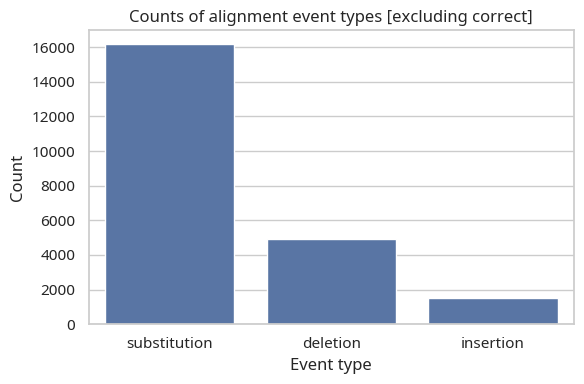

In [15]:
plt.figure(figsize=(6, 4))
sns.barplot(data=type_counts[type_counts["type"] != "correct"], x="type", y="count")
plt.title("Counts of alignment event types [excluding correct]")
plt.xlabel("Event type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


 ## Overall substitution table

In [16]:
sub_counts = (
    sub_df.groupby(["src", "tgt"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

sub_counts.to_csv(OUTDIR / "overall_substitution_counts.csv", index=False)
print("Len(all substitutions):", len(sub_counts))
sub_counts.head(25)


Len(all substitutions): 647


,src,tgt,count
349,z,s,1617
386,ð,d,1605
507,ɪ,i,1070
436,ɑ,ʌ,571
603,ʌ,æ,492
612,ʌ,ɪ,410
581,ʊ,ɔ,398
487,ɝ,ʌ,389
429,ɑ,ɔ,365
39,d,t,344


 ## Overall substitution heatmap (counts)

In [17]:
sub_matrix = sub_counts.pivot(index="src", columns="tgt", values="count").fillna(0)

src_totals = sub_matrix.sum(axis=1).sort_values(ascending=False)
tgt_totals = sub_matrix.sum(axis=0).sort_values(ascending=False)

TOP_SRC = 25
TOP_TGT = 25

top_src = src_totals.head(TOP_SRC).index
top_tgt = tgt_totals.head(TOP_TGT).index

sub_matrix_top = sub_matrix.loc[top_src, top_tgt]
sub_matrix_top.to_csv(OUTDIR / "overall_substitution_matrix_top.csv")

sub_matrix_top


tgt,s,d,ʌ,i,ɔ,ɪ,æ,t,ɑ,ɛ,...,ʃ,ŋ,z,ə,n,ɝ,p,θ,v,l
src,,,,,,,,,,,,,,,,,,,,,
ð,38.0,1605.0,7.0,2.0,1.0,2.0,0.0,71.0,5.0,4.0,...,1.0,0.0,93.0,3.0,4.0,1.0,1.0,111.0,0.0,51.0
ʌ,12.0,17.0,0.0,238.0,242.0,410.0,492.0,7.0,222.0,139.0,...,4.0,1.0,2.0,7.0,5.0,36.0,2.0,1.0,0.0,1.0
z,1617.0,10.0,40.0,7.0,41.0,5.0,0.0,12.0,1.0,6.0,...,8.0,0.0,0.0,1.0,3.0,9.0,0.0,10.0,1.0,0.0
ɪ,9.0,8.0,47.0,1070.0,3.0,0.0,42.0,1.0,66.0,291.0,...,1.0,3.0,0.0,3.0,3.0,1.0,1.0,0.0,0.0,4.0
ɑ,7.0,3.0,571.0,4.0,365.0,3.0,9.0,0.0,0.0,16.0,...,0.0,0.0,0.0,4.0,0.0,5.0,0.0,0.0,0.0,0.0
ɝ,0.0,4.0,389.0,3.0,31.0,10.0,0.0,1.0,11.0,18.0,...,1.0,0.0,3.0,127.0,2.0,0.0,1.0,0.0,1.0,7.0
d,51.0,0.0,19.0,2.0,6.0,27.0,9.0,344.0,1.0,24.0,...,17.0,18.0,12.0,14.0,27.0,3.0,4.0,4.0,5.0,4.0
ʊ,2.0,0.0,20.0,1.0,398.0,5.0,1.0,2.0,76.0,0.0,...,0.0,0.0,1.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0
v,3.0,1.0,7.0,7.0,3.0,5.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,43.0,0.0,0.0,1.0


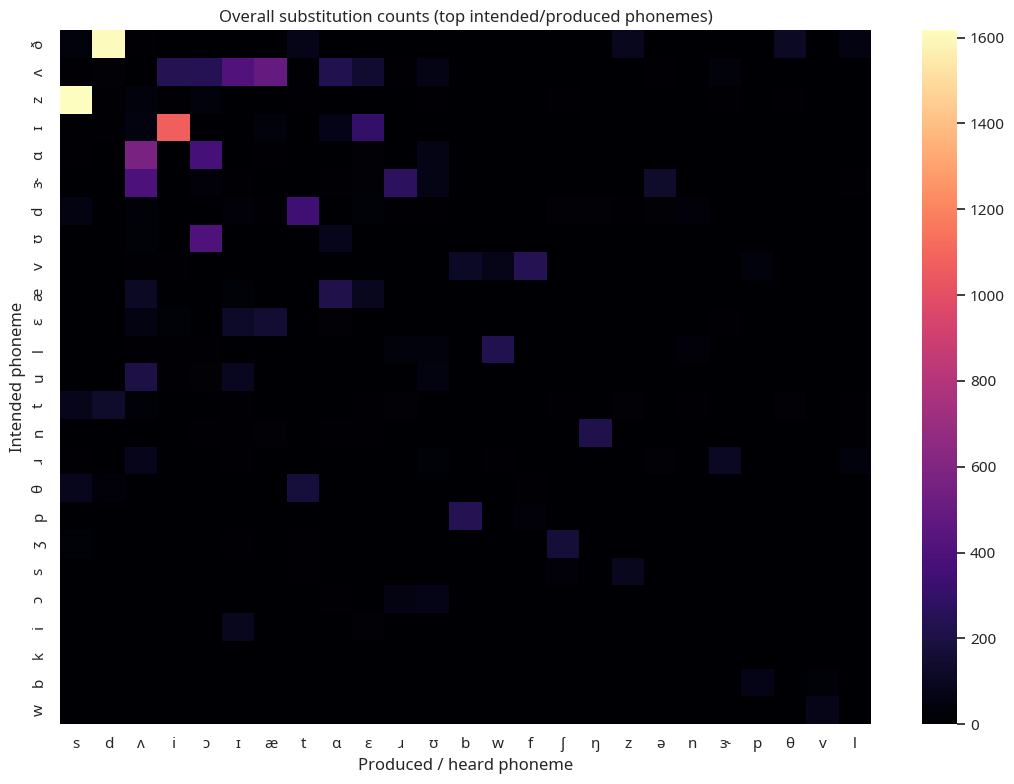

In [18]:
plt.figure(figsize=(11, 8))
sns.heatmap(sub_matrix_top, cmap="magma", annot=False)
plt.title("Overall substitution counts (top intended/produced phonemes)")
plt.xlabel("Produced / heard phoneme")
plt.ylabel("Intended phoneme")
plt.tight_layout()
plt.show()


 ## Overall substitution heatmap (row-normalised)



 This gives an approximate conditional distribution:

 P(produced phoneme | intended phoneme)

In [19]:
row_sums = sub_matrix.sum(axis=1).replace(0, np.nan)
sub_matrix_prob = sub_matrix.div(row_sums, axis=0)

sub_matrix_prob_top = sub_matrix_prob.loc[top_src, top_tgt]
sub_matrix_prob_top.to_csv(OUTDIR / "overall_substitution_prob_matrix_top.csv")

sub_matrix_prob_top


tgt,s,d,ʌ,i,ɔ,ɪ,æ,t,ɑ,ɛ,...,ʃ,ŋ,z,ə,n,ɝ,p,θ,v,l
src,,,,,,,,,,,,,,,,,,,,,
ð,0.018756,0.792201,0.003455,0.000987,0.000494,0.000987,0.000000,0.035044,0.002468,0.001974,...,0.000494,0.000000,0.045903,0.001481,0.001974,0.000494,0.000494,0.054788,0.000000,0.025173
ʌ,0.006009,0.008513,0.000000,0.119179,0.121182,0.205308,0.246370,0.003505,0.111167,0.069604,...,0.002003,0.000501,0.001002,0.003505,0.002504,0.018027,0.001002,0.000501,0.000000,0.000501
z,0.876898,0.005423,0.021692,0.003796,0.022234,0.002711,0.000000,0.006508,0.000542,0.003254,...,0.004338,0.000000,0.000000,0.000542,0.001627,0.004881,0.000000,0.005423,0.000542,0.000000
ɪ,0.005718,0.005083,0.029860,0.679797,0.001906,0.000000,0.026684,0.000635,0.041931,0.184879,...,0.000635,0.001906,0.000000,0.001906,0.001906,0.000635,0.000635,0.000000,0.000000,0.002541
ɑ,0.006573,0.002817,0.536150,0.003756,0.342723,0.002817,0.008451,0.000000,0.000000,0.015023,...,0.000000,0.000000,0.000000,0.003756,0.000000,0.004695,0.000000,0.000000,0.000000,0.000000
ɝ,0.000000,0.004180,0.406479,0.003135,0.032393,0.010449,0.000000,0.001045,0.011494,0.018809,...,0.001045,0.000000,0.003135,0.132706,0.002090,0.000000,0.001045,0.000000,0.001045,0.007315
d,0.076577,0.000000,0.028529,0.003003,0.009009,0.040541,0.013514,0.516517,0.001502,0.036036,...,0.025526,0.027027,0.018018,0.021021,0.040541,0.004505,0.006006,0.006006,0.007508,0.006006
ʊ,0.003442,0.000000,0.034423,0.001721,0.685026,0.008606,0.001721,0.003442,0.130809,0.000000,...,0.000000,0.000000,0.001721,0.005164,0.001721,0.000000,0.000000,0.000000,0.000000,0.000000
v,0.005917,0.001972,0.013807,0.013807,0.005917,0.009862,0.000000,0.001972,0.001972,0.001972,...,0.000000,0.000000,0.000000,0.001972,0.000000,0.001972,0.084813,0.000000,0.000000,0.001972


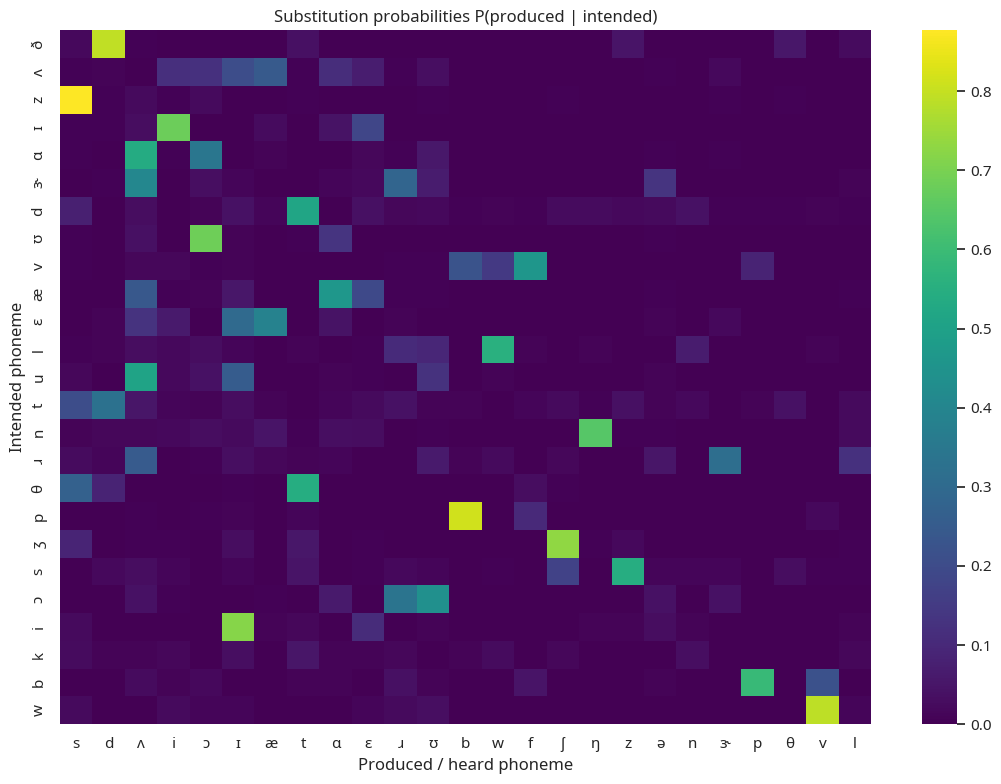

In [20]:
plt.figure(figsize=(11, 8))
sns.heatmap(sub_matrix_prob_top, cmap="viridis", annot=False)
plt.title("Substitution probabilities P(produced | intended)")
plt.xlabel("Produced / heard phoneme")
plt.ylabel("Intended phoneme")
plt.tight_layout()
plt.show()


 ## Top substitutions bar plot

In [45]:
top_subs = sub_counts.head(20).copy()
top_subs["mapping"] = top_subs["src"] + " -> " + top_subs["tgt"]

top_subs


,src,tgt,count,mapping
349,z,s,1617,z -> s
386,ð,d,1605,ð -> d
507,ɪ,i,1070,ɪ -> i
436,ɑ,ʌ,571,ɑ -> ʌ
603,ʌ,æ,492,ʌ -> æ
612,ʌ,ɪ,410,ʌ -> ɪ
581,ʊ,ɔ,398,ʊ -> ɔ
487,ɝ,ʌ,389,ɝ -> ʌ
429,ɑ,ɔ,365,ɑ -> ɔ
39,d,t,344,d -> t


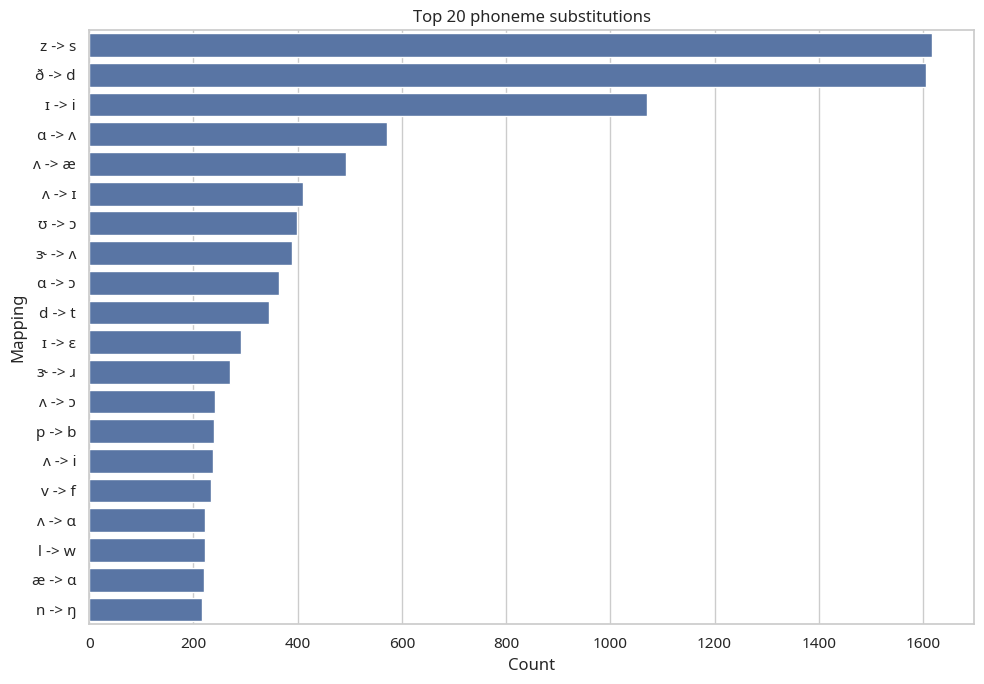

In [46]:
plt.figure(figsize=(10, 7))
sns.barplot(data=top_subs, y="mapping", x="count", orient="h")
plt.title("Top 20 phoneme substitutions")
plt.xlabel("Count")
plt.ylabel("Mapping")
plt.tight_layout()
plt.show()


 ## Per-intended-phoneme substitution totals



 Which intended phonemes get substituted most often?

In [23]:
src_sub_totals = (
    sub_df.groupby("src")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

src_sub_totals.to_csv(OUTDIR / "substitution_totals_by_intended_phoneme.csv", index=False)
src_sub_totals.head(20)


,src,count
21,ð,2026
32,ʌ,1997
19,z,1844
28,ɪ,1574
23,ɑ,1065
26,ɝ,957
2,d,666
31,ʊ,581
17,v,507
20,æ,474


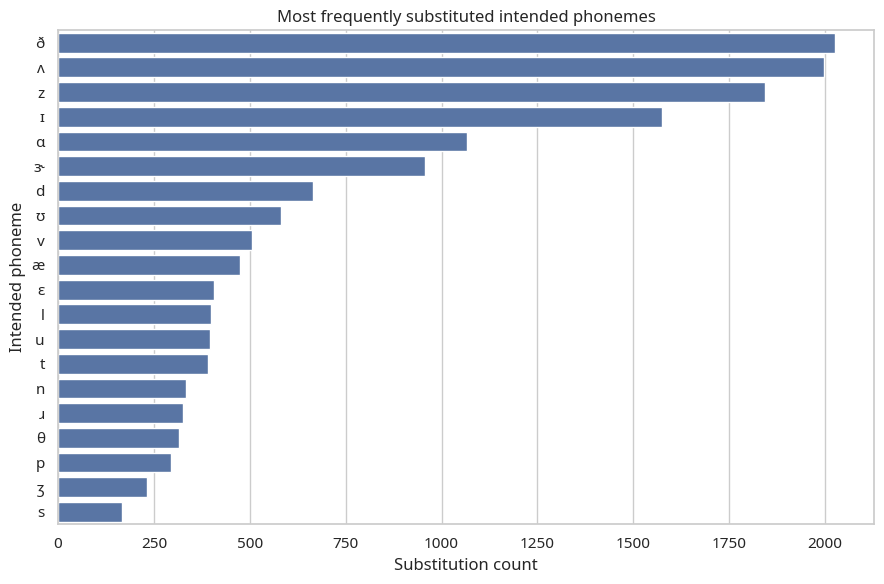

In [24]:
plt.figure(figsize=(9, 6))
sns.barplot(data=src_sub_totals.head(20), y="src", x="count", orient="h")
plt.title("Most frequently substituted intended phonemes")
plt.xlabel("Substitution count")
plt.ylabel("Intended phoneme")
plt.tight_layout()
plt.show()


 ## Per-produced-phoneme substitution totals



 Which produced phonemes appear most often as substitution outcomes?

In [25]:
tgt_sub_totals = (
    sub_df.groupby("tgt")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

tgt_sub_totals.to_csv(OUTDIR / "substitution_totals_by_produced_phoneme.csv", index=False)
tgt_sub_totals.head(20)


,tgt,count
14,s,2019
2,d,1842
33,ʌ,1609
6,i,1413
24,ɔ,1150
29,ɪ,866
20,æ,738
15,t,669
23,ɑ,666
26,ɛ,646


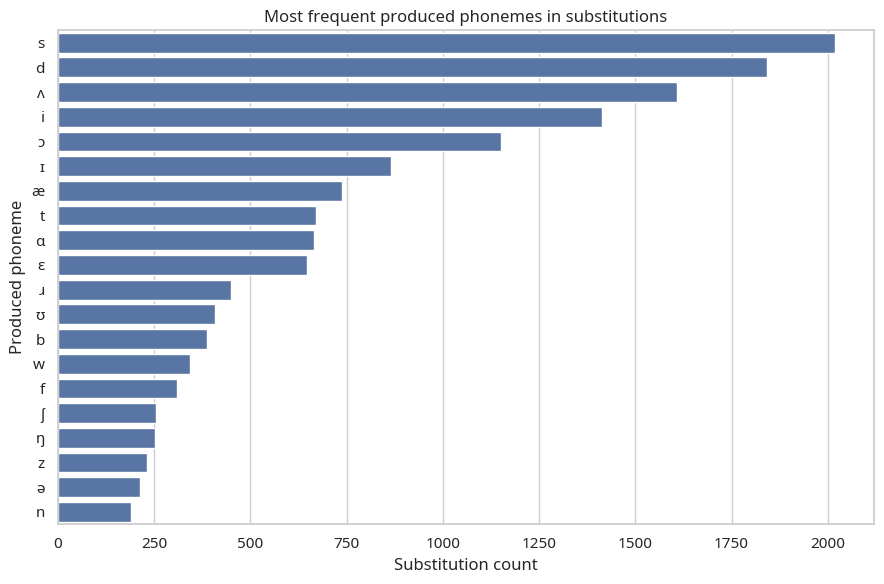

In [26]:
plt.figure(figsize=(9, 6))
sns.barplot(data=tgt_sub_totals.head(20), y="tgt", x="count", orient="h")
plt.title("Most frequent produced phonemes in substitutions")
plt.xlabel("Substitution count")
plt.ylabel("Produced phoneme")
plt.tight_layout()
plt.show()


 ## L1-specific substitution counts

In [27]:
sub_counts_l1 = (
    sub_df.groupby([L1_COL.replace(L1_COL, "L1") if False else "L1", "src", "tgt"])
    .size()
    .reset_index(name="count")
    .sort_values(["L1", "count"], ascending=[True, False])
)

sub_counts_l1.to_csv(OUTDIR / "substitution_counts_by_L1.csv", index=False)
sub_counts_l1.head(25)


,L1,src,tgt,count
96,Arabic,z,s,134
121,Arabic,ɑ,ɔ,108
201,Arabic,ʌ,æ,93
62,Arabic,p,b,92
166,Arabic,ɪ,ɛ,88
206,Arabic,ʌ,ɪ,82
152,Arabic,ɝ,ɹ,69
190,Arabic,ʊ,ɔ,68
110,Arabic,ð,z,62
157,Arabic,ɪ,i,57


 ## Top substitutions per L1

In [47]:
top_k = 10

top_subs_per_l1 = (
    sub_counts_l1.groupby("L1", group_keys=False)
    .head(top_k)
    .copy()
)

top_subs_per_l1["mapping"] = top_subs_per_l1["src"] + " -> " + top_subs_per_l1["tgt"]
top_subs_per_l1.to_csv(OUTDIR / "top_substitutions_per_L1.csv", index=False)

top_subs_per_l1.head(30)


,L1,src,tgt,count,pair,mapping
96,Arabic,z,s,134,z->s,z -> s
121,Arabic,ɑ,ɔ,108,ɑ->ɔ,ɑ -> ɔ
201,Arabic,ʌ,æ,93,ʌ->æ,ʌ -> æ
62,Arabic,p,b,92,p->b,p -> b
166,Arabic,ɪ,ɛ,88,ɪ->ɛ,ɪ -> ɛ
206,Arabic,ʌ,ɪ,82,ʌ->ɪ,ʌ -> ɪ
152,Arabic,ɝ,ɹ,69,ɝ->ɹ,ɝ -> ɹ
190,Arabic,ʊ,ɔ,68,ʊ->ɔ,ʊ -> ɔ
110,Arabic,ð,z,62,ð->z,ð -> z
157,Arabic,ɪ,i,57,ɪ->i,ɪ -> i


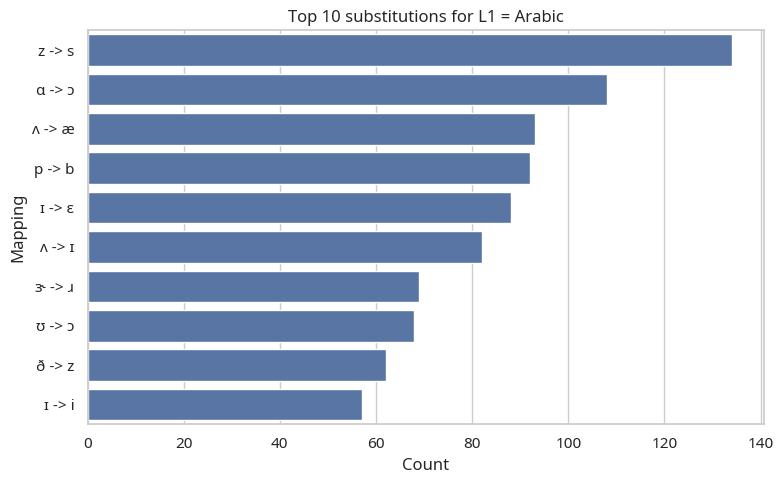

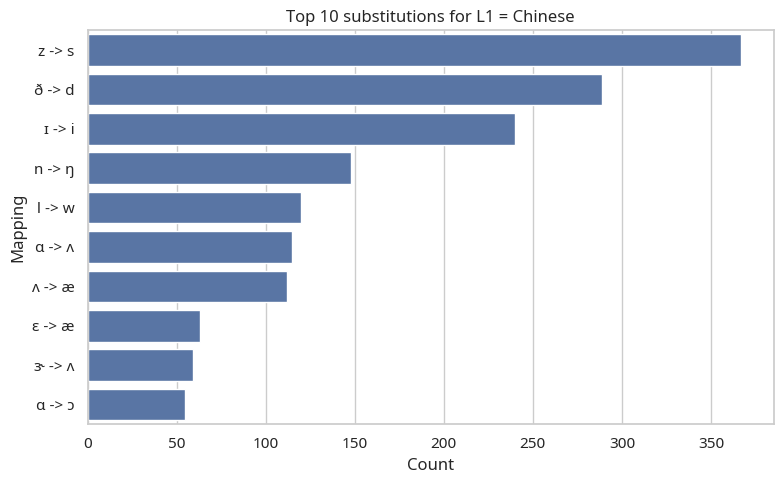

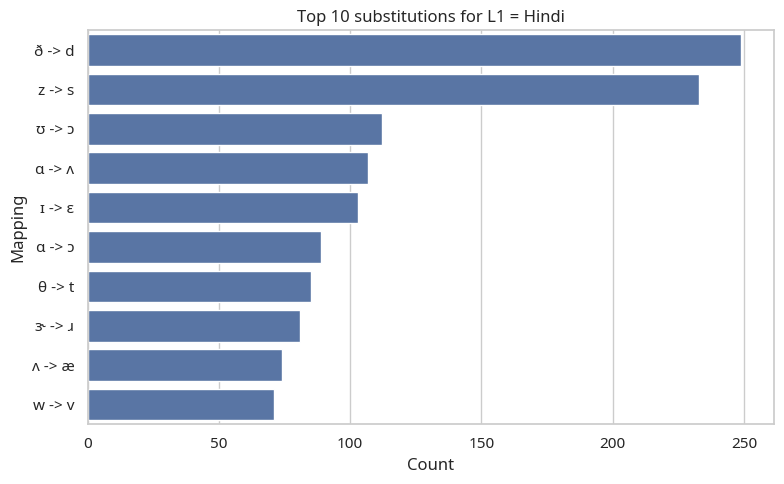

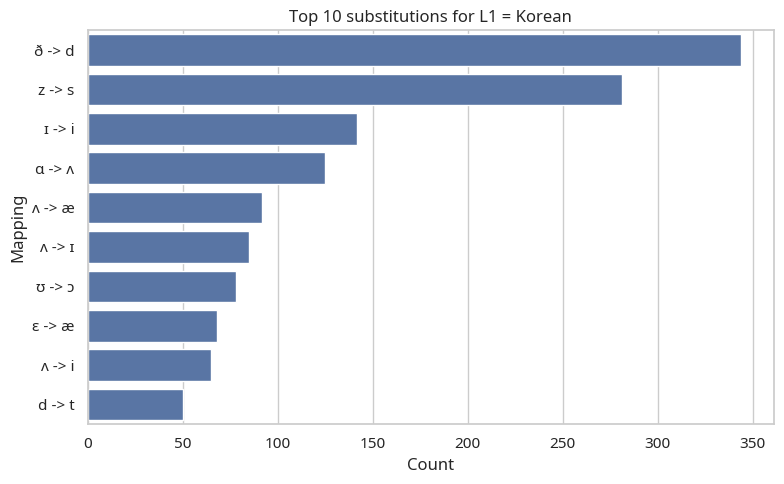

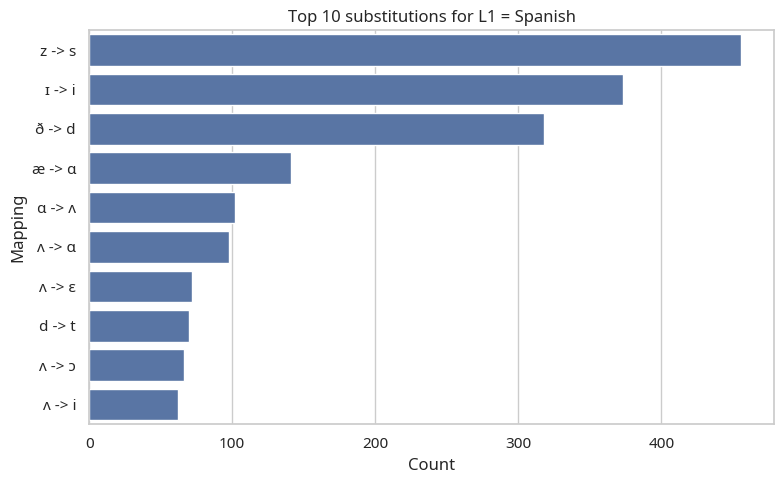

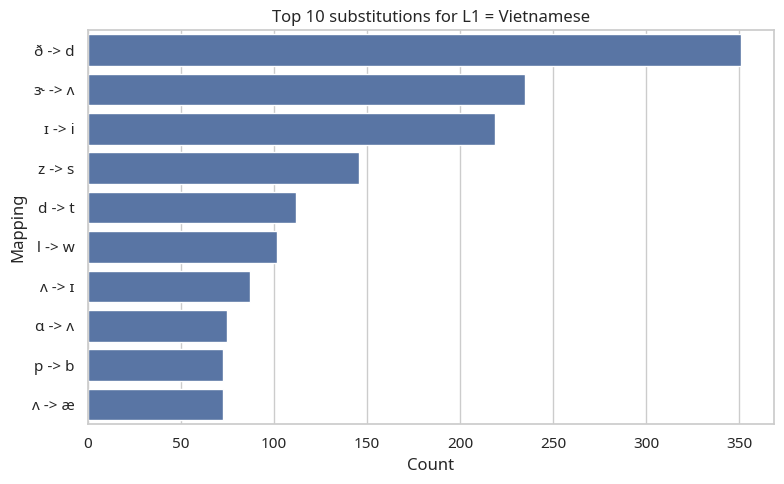

In [48]:
l1_list = top_subs_per_l1["L1"].unique()

for l1 in l1_list:
    plot_df = top_subs_per_l1[top_subs_per_l1["L1"] == l1].copy()

    plt.figure(figsize=(8, 5))
    sns.barplot(data=plot_df, y="mapping", x="count", orient="h")
    plt.title(f"Top {top_k} substitutions for L1 = {l1}")
    plt.xlabel("Count")
    plt.ylabel("Mapping")
    plt.tight_layout()
    plt.show()


 ## Heatmap for a chosen intended phoneme across L1s



 Example:

 - rows = L1

 - cols = produced phoneme

 - values = count



 This helps answer: "When intended phoneme X is misheard/misproduced, what does it become for different accents?"

In [30]:
EXAMPLE_SRC = "ɪ"   # change this to whichever intended phoneme you want

example_df = sub_counts_l1[sub_counts_l1["src"] == EXAMPLE_SRC].copy()
example_pivot = example_df.pivot(index="L1", columns="tgt", values="count").fillna(0)

example_pivot.to_csv(OUTDIR / f"example_substitution_matrix_{EXAMPLE_SRC}.csv")
example_pivot


tgt,a,b,d,f,i,j,k,l,n,p,...,ɔ,ə,ɛ,ɝ,ɡ,ɹ,ʃ,ʊ,ʌ,ʒ
L1,,,,,,,,,,,,,,,,,,,,,
Arabic,0.0,0.0,0.0,0.0,57.0,1.0,0.0,0.0,0.0,1.0,...,1.0,1.0,88.0,1.0,0.0,2.0,0.0,3.0,10.0,1.0
Chinese,0.0,0.0,1.0,0.0,240.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,28.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0
Hindi,0.0,0.0,0.0,0.0,39.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,103.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0
Korean,0.0,0.0,5.0,0.0,142.0,0.0,0.0,2.0,0.0,0.0,...,0.0,1.0,22.0,0.0,0.0,1.0,0.0,0.0,11.0,0.0
Spanish,0.0,1.0,1.0,1.0,373.0,0.0,0.0,2.0,2.0,0.0,...,1.0,0.0,19.0,0.0,1.0,1.0,0.0,1.0,8.0,0.0
Vietnamese,1.0,0.0,1.0,0.0,219.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,31.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0


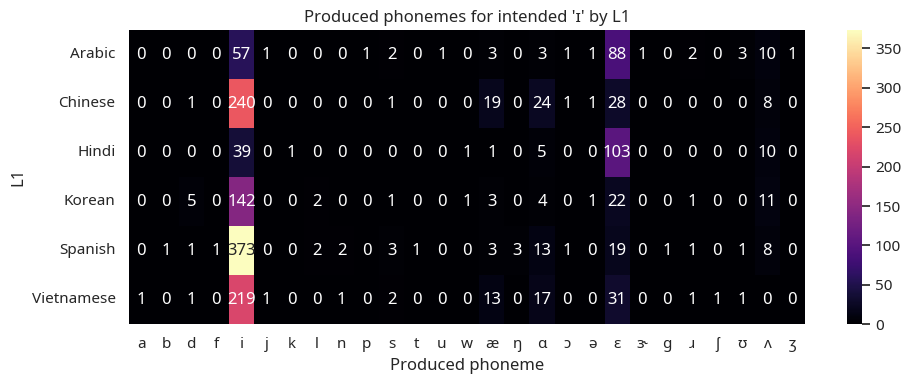

In [31]:
plt.figure(figsize=(10, 4))
sns.heatmap(example_pivot, cmap="magma", annot=True, fmt=".0f")
plt.title(f"Produced phonemes for intended '{EXAMPLE_SRC}' by L1")
plt.xlabel("Produced phoneme")
plt.ylabel("L1")
plt.tight_layout()
plt.show()


 ## Substitution matrices by L1



 Save one full substitution matrix per L1 and show a heatmap for the top phonemes.

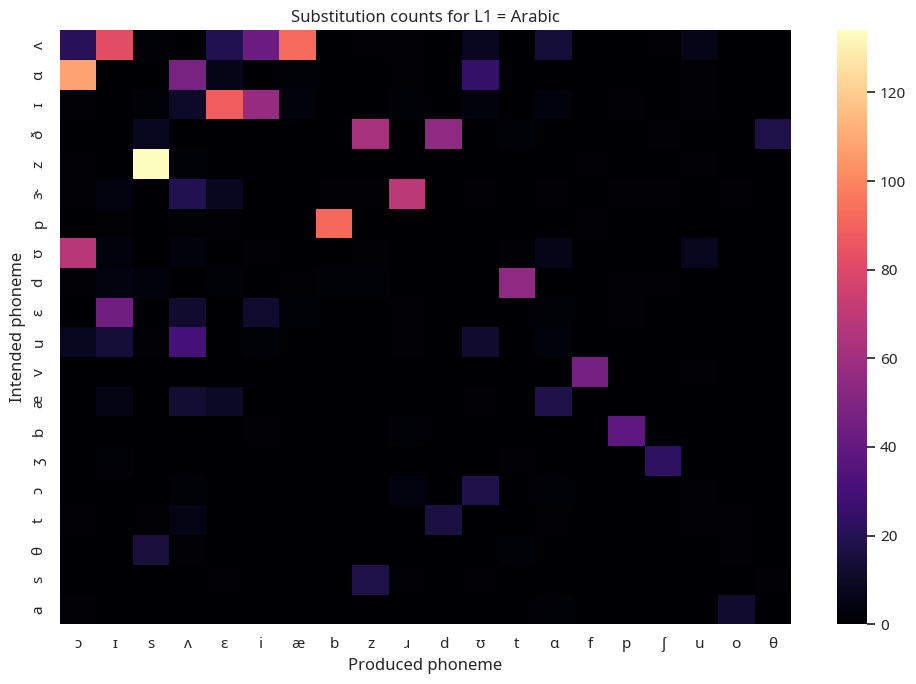

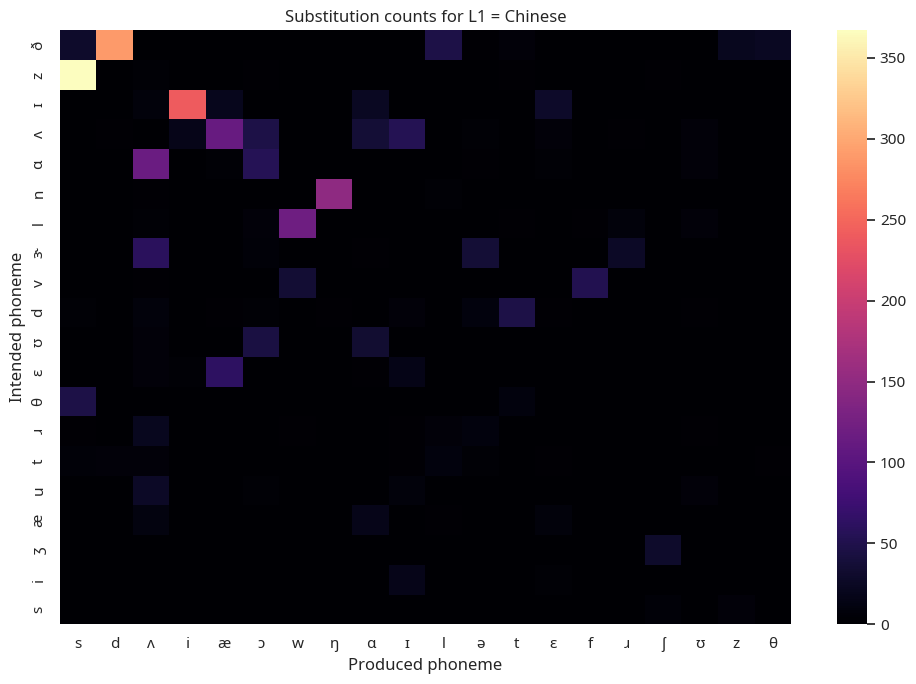

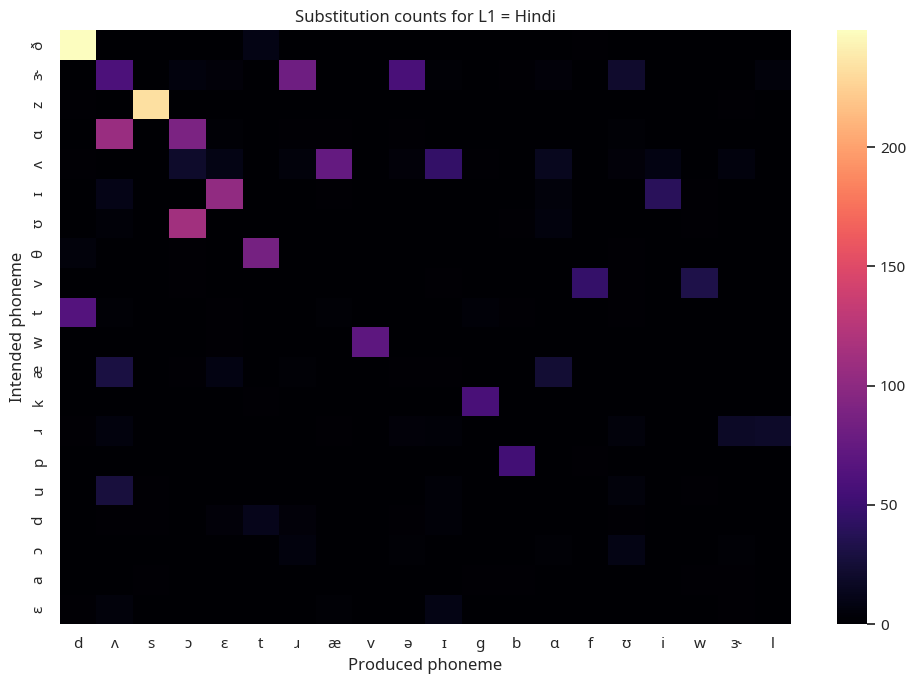

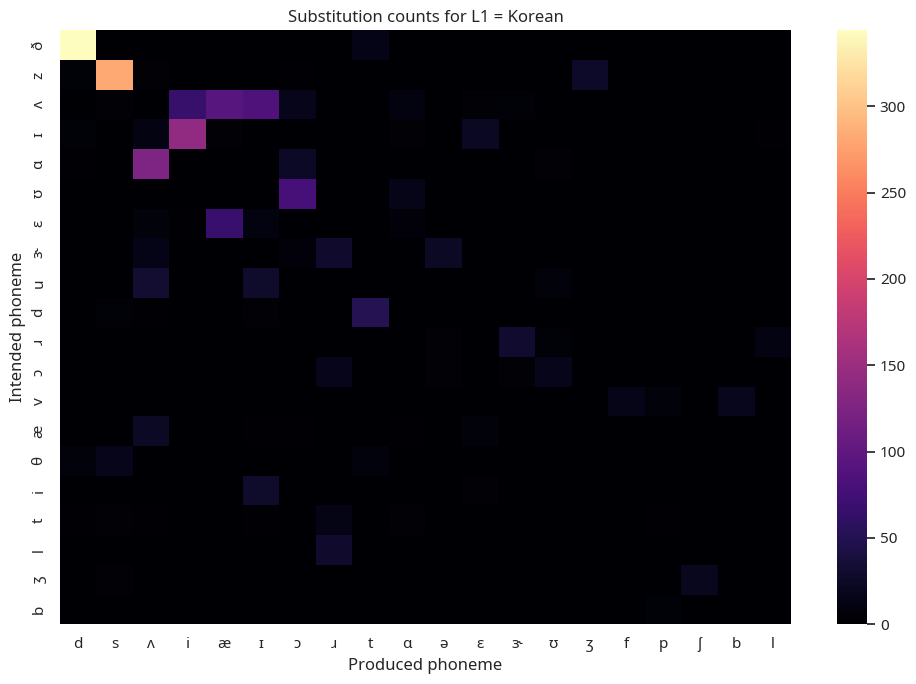

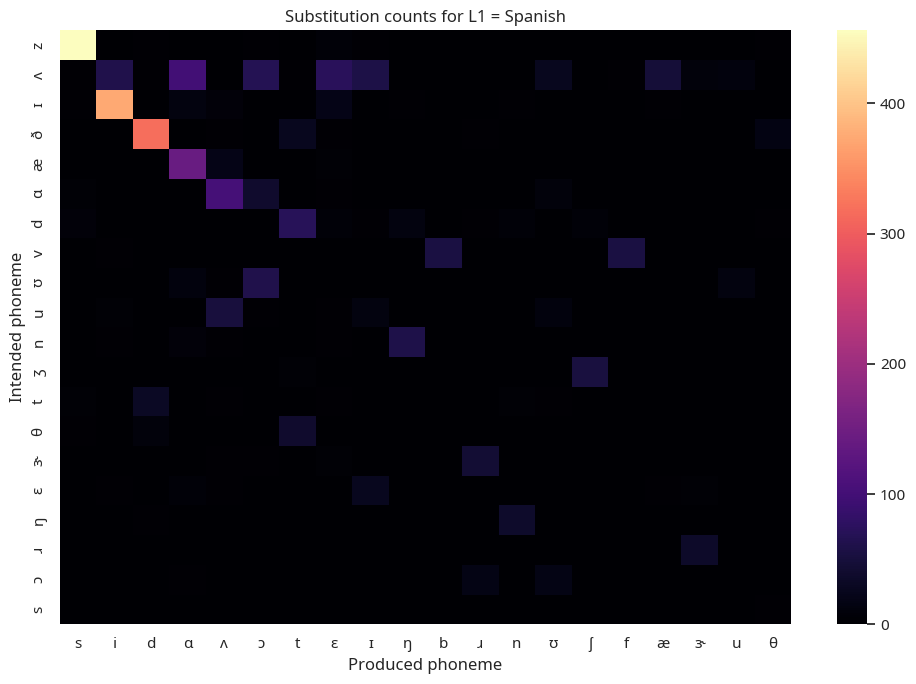

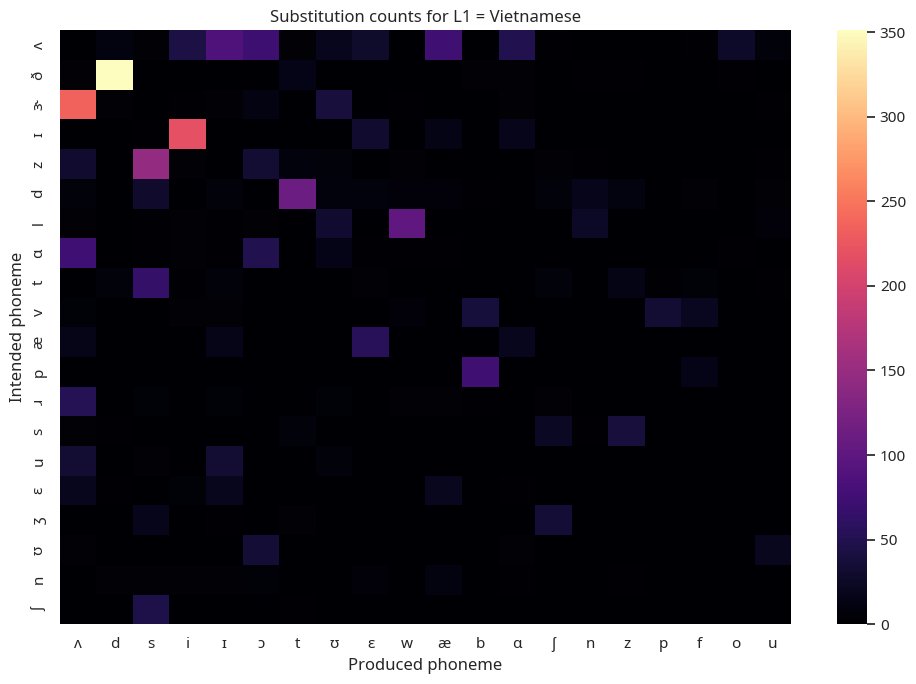

In [32]:
l1_values = sorted(sub_df["L1"].dropna().unique())

for l1 in l1_values:
    tmp = sub_df[sub_df["L1"] == l1]
    mat = (
        tmp.groupby(["src", "tgt"])
        .size()
        .reset_index(name="count")
        .pivot(index="src", columns="tgt", values="count")
        .fillna(0)
    )

    mat.to_csv(OUTDIR / f"substitution_matrix_{l1}.csv")

    src_tot = mat.sum(axis=1).sort_values(ascending=False)
    tgt_tot = mat.sum(axis=0).sort_values(ascending=False)

    top_src_l1 = src_tot.head(20).index
    top_tgt_l1 = tgt_tot.head(20).index

    mat_top = mat.loc[top_src_l1, top_tgt_l1]

    plt.figure(figsize=(10, 7))
    sns.heatmap(mat_top, cmap="magma", annot=False)
    plt.title(f"Substitution counts for L1 = {l1}")
    plt.xlabel("Produced phoneme")
    plt.ylabel("Intended phoneme")
    plt.tight_layout()
    plt.show()


 ## Correlation of substitution profiles across L1s



 Represent each L1 as a vector over substitution pairs (src -> tgt),

 then compute correlation between those vectors.

In [33]:
sub_counts_l1["pair"] = sub_counts_l1["src"] + "->" + sub_counts_l1["tgt"]

l1_totals = (
    sub_counts_l1.groupby("L1")["count"]
    .sum()
    .rename("total")
)

sub_prob_l1 = sub_counts_l1.join(l1_totals, on="L1")
sub_prob_l1["prob"] = sub_prob_l1["count"] / sub_prob_l1["total"]

l1_pair_matrix = (
    sub_prob_l1.pivot(index="L1", columns="pair", values="prob")
    .fillna(0.0)
)

l1_pair_matrix.to_csv(OUTDIR / "L1_substitution_profile_matrix.csv")

corr_l1 = l1_pair_matrix.T.corr()
corr_l1.to_csv(OUTDIR / "L1_substitution_profile_correlation.csv")

corr_l1


L1,Arabic,Chinese,Hindi,Korean,Spanish,Vietnamese
L1,,,,,,
Arabic,1.000000,0.642573,0.746355,0.646110,0.634839,0.572691
Chinese,0.642573,1.000000,0.772304,0.886280,0.895624,0.778938
Hindi,0.746355,0.772304,1.000000,0.839216,0.739243,0.698345
Korean,0.646110,0.886280,0.839216,1.000000,0.867649,0.782181
Spanish,0.634839,0.895624,0.739243,0.867649,1.000000,0.732390
Vietnamese,0.572691,0.778938,0.698345,0.782181,0.732390,1.000000


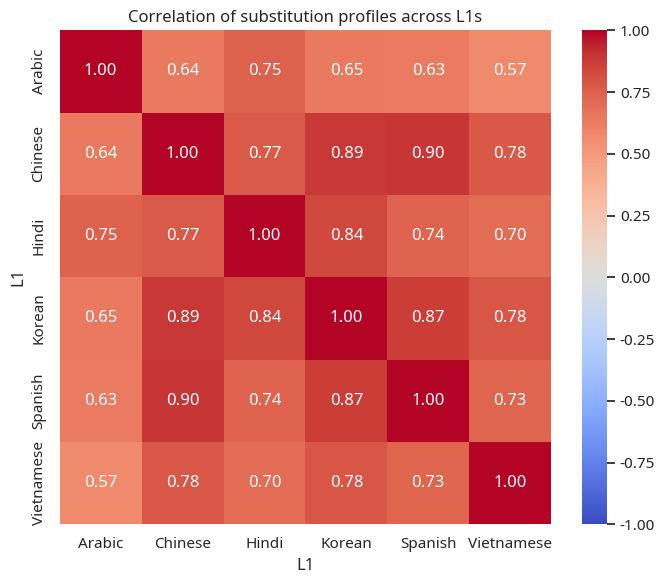

In [34]:
plt.figure(figsize=(7, 6))
sns.heatmap(corr_l1, cmap="coolwarm", vmin=-1, vmax=1, annot=True, fmt=".2f")
plt.title("Correlation of substitution profiles across L1s")
plt.xlabel("L1")
plt.ylabel("L1")
plt.tight_layout()
plt.show()


 ## Cosine-similarity-style overlap across L1s



 Correlation is one view. Another useful one is cosine similarity between

 substitution-probability vectors.

In [35]:
def cosine_similarity_df(mat: pd.DataFrame):
    X = mat.values
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1, norms)
    Xn = X / norms
    sim = Xn @ Xn.T
    return pd.DataFrame(sim, index=mat.index, columns=mat.index)

cos_l1 = cosine_similarity_df(l1_pair_matrix)
cos_l1.to_csv(OUTDIR / "L1_substitution_profile_cosine_similarity.csv")

cos_l1


L1,Arabic,Chinese,Hindi,Korean,Spanish,Vietnamese
L1,,,,,,
Arabic,1.000000,0.657440,0.756926,0.657668,0.648179,0.596947
Chinese,0.657440,1.000000,0.780476,0.889406,0.898879,0.787764
Hindi,0.756926,0.780476,1.000000,0.843791,0.747673,0.711445
Korean,0.657668,0.889406,0.843791,1.000000,0.871272,0.787868
Spanish,0.648179,0.898879,0.747673,0.871272,1.000000,0.741599
Vietnamese,0.596947,0.787764,0.711445,0.787868,0.741599,1.000000


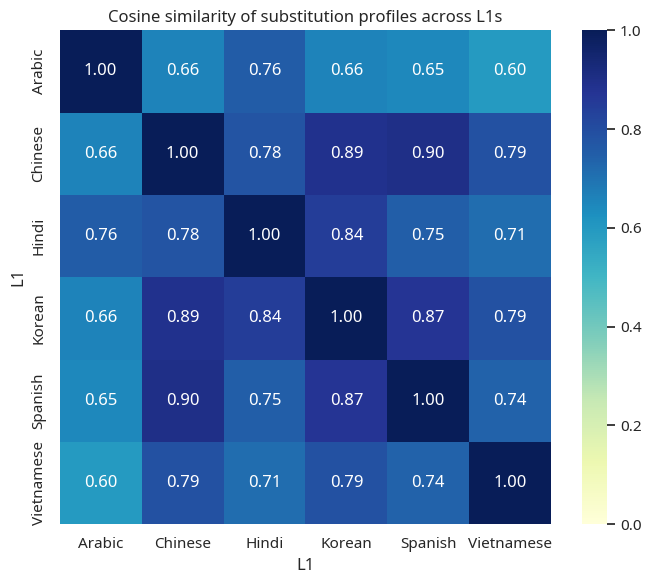

In [36]:
plt.figure(figsize=(7, 6))
sns.heatmap(cos_l1, cmap="YlGnBu", vmin=0, vmax=1, annot=True, fmt=".2f")
plt.title("Cosine similarity of substitution profiles across L1s")
plt.xlabel("L1")
plt.ylabel("L1")
plt.tight_layout()
plt.show()


 ## Which substitutions are most accent-specific?



 We compute, for each substitution pair, how unevenly it is distributed across L1s.

 A quick measure is coefficient of variation across L1-specific probabilities.

In [37]:
pair_l1 = (
    sub_prob_l1.pivot(index="pair", columns="L1", values="prob")
    .fillna(0.0)
)

pair_stats = pd.DataFrame(index=pair_l1.index)
pair_stats["mean_prob"] = pair_l1.mean(axis=1)
pair_stats["std_prob"] = pair_l1.std(axis=1)
pair_stats["cv"] = pair_stats["std_prob"] / pair_stats["mean_prob"].replace(0, np.nan)

pair_stats = pair_stats.sort_values("cv", ascending=False)
pair_stats.to_csv(OUTDIR / "accent_specific_substitution_pairs.csv")

pair_stats.head(25)


,mean_prob,std_prob,cv
pair,,,
θ->ʌ,0.000090,0.000220,2.44949
θ->ʊ,0.000074,0.000182,2.44949
a->d,0.000057,0.000139,2.44949
ʒ->o,0.000052,0.000126,2.44949
ʒ->l,0.000057,0.000139,2.44949
ʒ->k,0.000045,0.000110,2.44949
ʒ->j,0.000309,0.000758,2.44949
ʒ->i,0.000057,0.000139,2.44949
ʌ->θ,0.000045,0.000110,2.44949


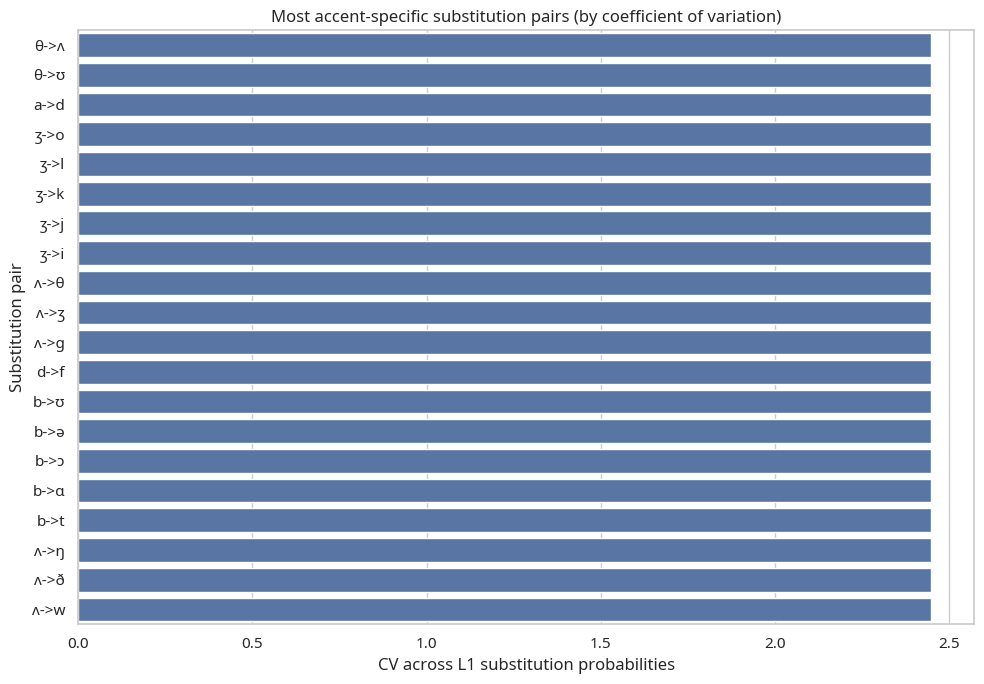

In [38]:
top_accent_specific = pair_stats.head(20).reset_index().rename(columns={"index": "pair"})

plt.figure(figsize=(10, 7))
sns.barplot(data=top_accent_specific, y="pair", x="cv", orient="h")
plt.title("Most accent-specific substitution pairs (by coefficient of variation)")
plt.xlabel("CV across L1 substitution probabilities")
plt.ylabel("Substitution pair")
plt.tight_layout()
plt.show()


 ## Accent-specific substitution table for selected pairs



 Inspect a few high-interest substitutions across L1s.

In [39]:
SELECTED_PAIRS = top_accent_specific["pair"].head(10).tolist()

selected_pair_table = pair_l1.loc[SELECTED_PAIRS].copy()
selected_pair_table.to_csv(OUTDIR / "selected_accent_specific_pairs_by_L1.csv")

selected_pair_table


L1,Arabic,Chinese,Hindi,Korean,Spanish,Vietnamese
pair,,,,,,
θ->ʌ,0.000538,0.00000,0.000000,0.0,0.000000,0.000000
θ->ʊ,0.000000,0.00000,0.000445,0.0,0.000000,0.000000
a->d,0.000000,0.00034,0.000000,0.0,0.000000,0.000000
ʒ->o,0.000000,0.00000,0.000000,0.0,0.000309,0.000000
ʒ->l,0.000000,0.00034,0.000000,0.0,0.000000,0.000000
ʒ->k,0.000000,0.00000,0.000000,0.0,0.000000,0.000269
ʒ->j,0.000000,0.00000,0.000000,0.0,0.001856,0.000000
ʒ->i,0.000000,0.00034,0.000000,0.0,0.000000,0.000000
ʌ->θ,0.000000,0.00000,0.000000,0.0,0.000000,0.000269


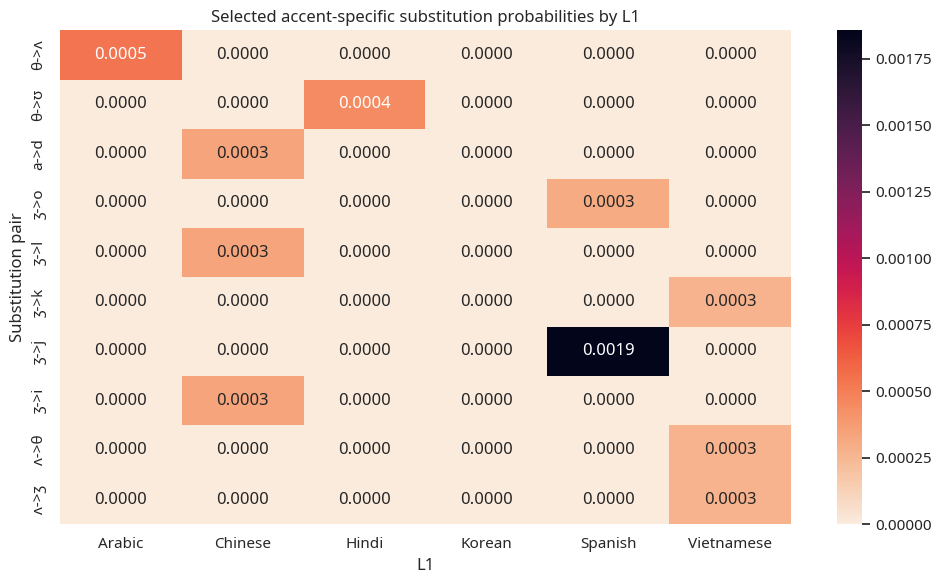

In [40]:
plt.figure(figsize=(10, 6))
sns.heatmap(selected_pair_table, cmap="rocket_r", annot=True, fmt=".4f")
plt.title("Selected accent-specific substitution probabilities by L1")
plt.xlabel("L1")
plt.ylabel("Substitution pair")
plt.tight_layout()
plt.show()


 ## Speaker-level variation



 Optional but useful: compare substitution rates by speaker.

In [41]:
speaker_sub_counts = (
    sub_df.groupby("speaker_code")
    .size()
    .reset_index(name="substitution_count")
    .sort_values("substitution_count", ascending=False)
)

speaker_sub_counts.to_csv(OUTDIR / "speaker_substitution_counts.csv", index=False)
speaker_sub_counts.head(20)


,speaker_code,substitution_count
16,THV,1089
3,EBVS,954
7,HQTV,947
17,TLV,922
4,ERMS,878
8,LXC,838
2,BWC,816
12,PNV,755
11,NJS,748
10,NCC,679


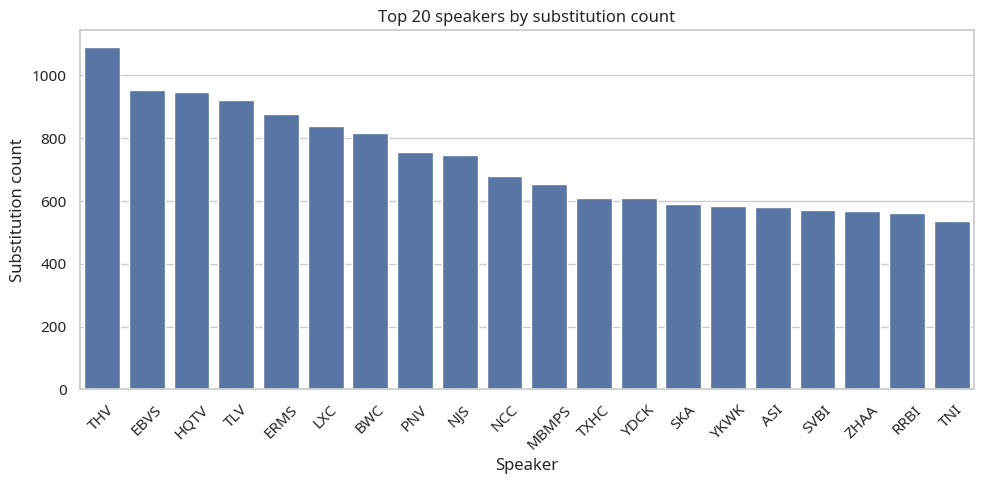

In [42]:
plt.figure(figsize=(10, 5))
sns.barplot(data=speaker_sub_counts.head(20), x="speaker_code", y="substitution_count")
plt.title("Top 20 speakers by substitution count")
plt.xlabel("Speaker")
plt.ylabel("Substitution count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


 ## Substitution rate by L1



 Here we compute:

 substitutions / (substitutions + correct mappings)

 i.e. among aligned non-gap phoneme pairs, how often does each L1 substitute?

In [43]:
pair_events = mapping_df[mapping_df["type"].isin(["correct", "substitution"])].copy()

l1_rate = (
    pair_events.groupby(["L1", "type"])
    .size()
    .reset_index(name="count")
    .pivot(index="L1", columns="type", values="count")
    .fillna(0)
)

l1_rate["substitution_rate"] = l1_rate["substitution"] / (
    l1_rate["substitution"] + l1_rate["correct"]
)

l1_rate = l1_rate.sort_values("substitution_rate", ascending=False)
l1_rate.to_csv(OUTDIR / "substitution_rate_by_L1.csv")

l1_rate


type,correct,substitution,substitution_rate
L1,,,
Vietnamese,16291,3713,0.185613
Spanish,17815,3233,0.153601
Chinese,17474,2944,0.144187
Hindi,18253,2249,0.109697
Korean,18526,2168,0.104765
Arabic,18880,1858,0.089594


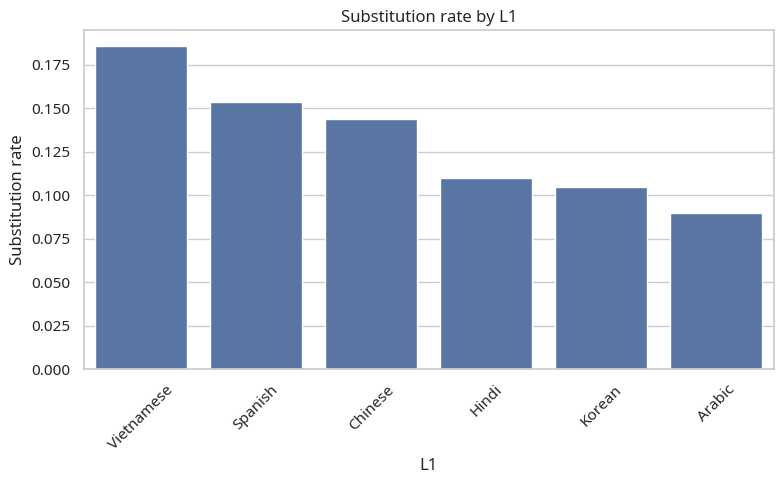

In [44]:
plt.figure(figsize=(8, 5))
sns.barplot(x=l1_rate.index, y=l1_rate["substitution_rate"].values)
plt.title("Substitution rate by L1")
plt.xlabel("L1")
plt.ylabel("Substitution rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


 ## Final notes



 Output files were written to:

 - `mapping_analysis_outputs/raw_alignment_records.csv`

 - `mapping_analysis_outputs/overall_substitution_counts.csv`

 - `mapping_analysis_outputs/substitution_counts_by_L1.csv`

 - and several matrix/correlation CSV files



 Next possible extensions:

 - Handle multi-character IPA phones properly (e.g. affricates)

 - Analyse insertions and deletions separately

 - Group substitutions by phonological class (vowel/consonant, manner/place)

 - Compare canonical G2P vs produced phones using PanPhon feature distance